# Lesion Generation QA Report

This notebook generates sample lesions (EDH, IPH, Fracture) and displays them for visual verification. It also checks volume and intensity against targets.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add src to path
project_root = Path('..').resolve()
sys.path.append(str(project_root / 'src'))

from insilicoICH.lesion_definition import LesionFactory

/home/sarah/Dev/InSilicoICH/src/insilicoICH/phantoms/head_phantoms.py:36: UserWarning: 
The environment variable `PHANTOM_DIRECTORY` has not been set, this is needed
to locate stored base phantom files for the NIHPD and MIDA head phantoms.

If these phantom files cannot be located, NIHPD phantoms will be downloaded to
your working directory: /home/sarah/Dev/InSilicoICH/src

MIDA phantom files need to be downloaded manually and added to this directory,
see `MIDA_Head_Phantom` for details.

Please do one of the following:

1. create a file called `.env` in this project's working directory and add:

`PHANTOM_DIRECTORY=/path/to/phantoms`

or

2. in your terminal `export PHANTOM_DIRECTORY=/path/to_phantoms`

  warn(f'''


In [2]:
def show_lesion(lesion, boundary_slice=None, title="Lesion"):
    center_z = lesion.coords_voxel[0]
    if center_z < 0 or center_z >= lesion.mask.shape[0]:
        center_z = lesion.mask.shape[0] // 2
    
    mask_slice = lesion.mask[center_z]
    img_slice = lesion.image[center_z]
    
    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(mask_slice, cmap='gray')
    ax[0].set_title(f"{title} Mask (z={center_z})")
    
    ax[1].imshow(img_slice, cmap='gray')
    ax[1].set_title(f"{title} Texture")
    
    if boundary_slice is not None:
        ax[2].imshow(boundary_slice[center_z], cmap='gray')
        ax[2].imshow(mask_slice, cmap='jet', alpha=0.5)
        ax[2].set_title("Overlap")
        
        # Show 3D projection/max intensity to see full shape
        ax[3].imshow(np.max(lesion.mask, axis=0), cmap='gray')
        ax[3].set_title("MIP (Axial)")
    else:
        ax[2].axis('off')
        ax[3].axis('off')
    plt.show()
    
    print(f"Target Volume: {target_vol:.2f} mL | Achieved: {lesion.volume_ml:.2f} mL")
    print(f"Target HU: {target_hu} | Achieved: {lesion.intensity_HU:.2f}")

## 1. Epidural Hematoma (EDH)

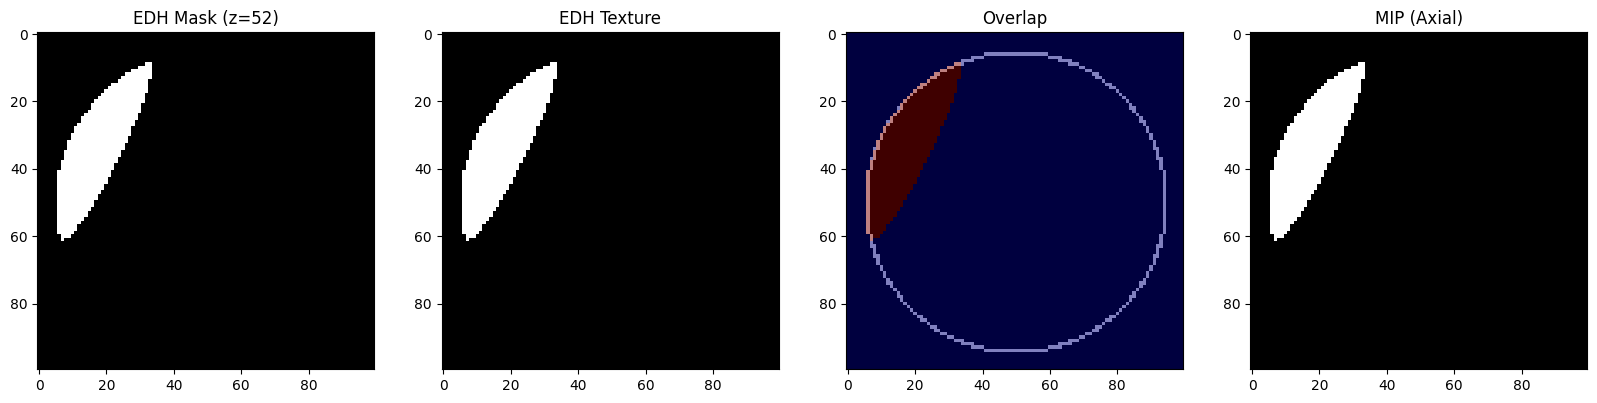

Target Volume: 10.00 mL | Achieved: 10.34 mL
Target HU: 60 | Achieved: 60.00


In [3]:
# Mock Dura - Spherical Shell for realism
shape = (100, 100, 100)
dura = np.zeros(shape, dtype=bool)
z, y, x = np.ogrid[:100, :100, :100]
center = (50, 50, 50)
dist_sq = (z - center[0])**2 + (y - center[1])**2 + (x - center[2])**2
# Inner boundary of skull/outer boundary of brain ~45 voxels
dura[(dist_sq <= 45**2) & (dist_sq >= 44**2)] = True

target_vol = 10.0
target_hu = 60

# Explicit seed < 22000 to prevent segfault in noise library
lesion = LesionFactory.create('EDH', boundary=dura, spacings=(1, 1, 1), seed=1234)
lesion.generate(volume_ml=target_vol, intensity_hu=target_hu)

show_lesion(lesion, dura, "EDH")

## 2. Intraparenchymal Hemorrhage (IPH)

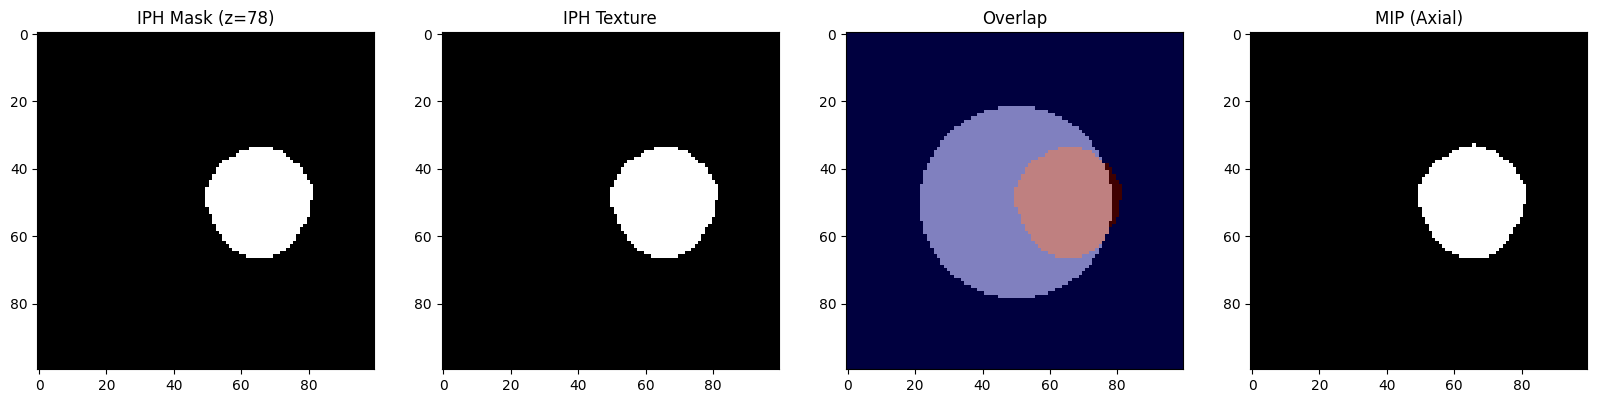

Target Volume: 15.00 mL | Achieved: 15.00 mL
Target HU: 50 | Achieved: 50.00


In [4]:
# Mock Brain
brain = np.zeros(shape, dtype=bool)
z, y, x = np.ogrid[:100, :100, :100]
center = (50, 50, 50)
brain[((z-50)**2 + (y-50)**2 + (x-50)**2) <= 40**2] = True

target_vol = 15.0
target_hu = 50

# Explicit seed < 22000 to prevent segfault
lesion = LesionFactory.create('IPH', boundary=brain, spacings=(1, 1, 1), seed=4321)
lesion.generate(volume_ml=target_vol, intensity_hu=target_hu)

show_lesion(lesion, brain, "IPH")

## 3. Fracture

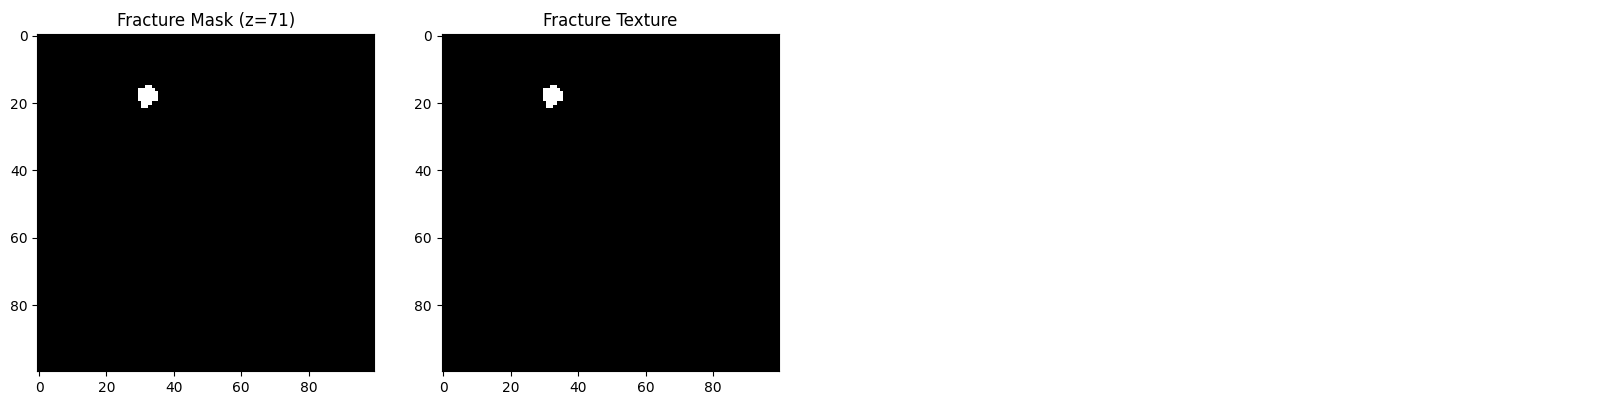

Target Volume: 0.00 mL | Achieved: 0.22 mL
Target HU: -1000 | Achieved: 1.00


In [5]:
# Mock Skull
skull = np.zeros(shape, dtype=np.uint8)
dist_sq = (z-50)**2 + (y-50)**2 + (x-50)**2
skull[(dist_sq <= 45**2) & (dist_sq >= 40**2)] = 1

target_vol = 0 # Not targeted
target_hu = -1000

# Explicit seed < 22000
lesion = LesionFactory.create('Fracture', boundary=skull, spacings=(1, 1, 1), seed=5678)
lesion.generate(fracture_length=50, thickness=2)

show_lesion(lesion, None, "Fracture")